## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



#### Probabilistic Regression for make_moons dataset
* Step 1: Implement Vanilla FNN
* Step 2: Implement Mixture Density Network
* Step 3: Implement Ensemble Learning

In [1]:
%load_ext autoreload
%autoreload 2

#### Part 1. Load make_moons Dataset from sklearn

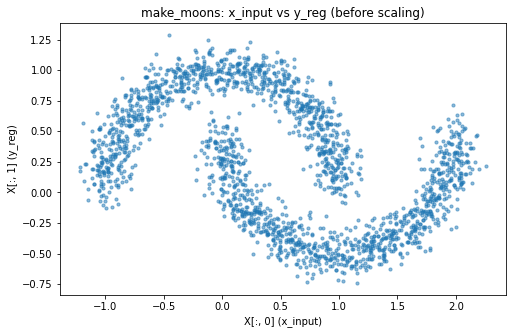

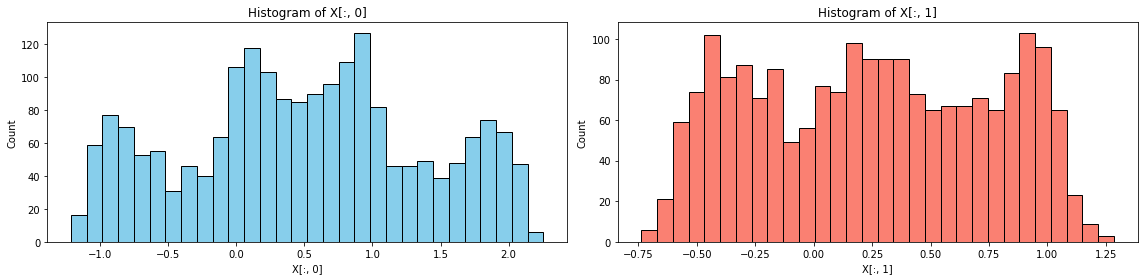

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# Load and preprocess data
X, y = make_moons(n_samples=2000, noise=0.1, random_state=42)
# Predict X[:, 1] (y_reg) from X[:, 0] (x_input)
x_input = X[:, [0]]
y_reg = X[:, 1]

# Plot x_input vs y_reg before scaling
plt.figure(figsize=(8, 5))
plt.scatter(x_input, y_reg, alpha=0.5, s=10)
plt.xlabel("X[:, 0] (x_input)")
plt.ylabel("X[:, 1] (y_reg)")
plt.title("make_moons: x_input vs y_reg (before scaling)")
plt.show()

# Add histogram plots of X and y
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
axs[0].hist(X[:, 0], bins=30, color='skyblue', edgecolor='black')
axs[0].set_title("Histogram of X[:, 0]")
axs[0].set_xlabel("X[:, 0]")
axs[0].set_ylabel("Count")

axs[1].hist(X[:, 1], bins=30, color='salmon', edgecolor='black')
axs[1].set_title("Histogram of X[:, 1]")
axs[1].set_xlabel("X[:, 1]")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    x_input, y_reg, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert to torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).unsqueeze(1)

#### Part 2. Build Feedforward Neural Network to Learn the Function

In [3]:
# Vanilla Feedforward Neural Network (FNN) for 1D regression
class FeedforwardNN(nn.Module):
    def __init__(self, n_hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FeedforwardNN(n_hidden=64)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-4, verbose=False
)

# Early stopping parameters
best_val_loss = float('inf')
best_epoch = -1
patience = 20
epochs_no_improve = 0
best_model_state = None

train_losses = []
val_losses = []
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation loss
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_test_t)
        val_loss = criterion(y_val_pred, y_test_t)
        val_losses.append(val_loss.item())

    # Scheduler step
    scheduler.step(val_loss)

    # Print train/val loss and learning rate
    current_lr = optimizer.param_groups[0]['lr']
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f} | LR: {current_lr:.6f}")

    # Early stopping check
    if val_loss.item() < best_val_loss - 1e-6:
        best_val_loss = val_loss.item()
        best_epoch = epoch
        best_model_state = model.state_dict()
        epochs_no_improve = 0

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)


d:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/200 | Train Loss: 0.892748 | Val Loss: 0.894307 | LR: 0.010000
Epoch 11/200 | Train Loss: 0.707055 | Val Loss: 0.771174 | LR: 0.010000
Epoch 21/200 | Train Loss: 0.637455 | Val Loss: 0.719827 | LR: 0.010000
Epoch 31/200 | Train Loss: 0.602902 | Val Loss: 0.687560 | LR: 0.010000
Epoch 41/200 | Train Loss: 0.591397 | Val Loss: 0.669960 | LR: 0.010000
Epoch 51/200 | Train Loss: 0.587127 | Val Loss: 0.665081 | LR: 0.010000
Epoch 61/200 | Train Loss: 0.584635 | Val Loss: 0.662894 | LR: 0.010000
Epoch 71/200 | Train Loss: 0.583839 | Val Loss: 0.662316 | LR: 0.010000
Epoch 81/200 | Train Loss: 0.583374 | Val Loss: 0.662102 | LR: 0.010000
Epoch 91/200 | Train Loss: 0.583094 | Val Loss: 0.661703 | LR: 0.005000
Epoch 101/200 | Train Loss: 0.582897 | Val Loss: 0.661865 | LR: 0.002500
Epoch 111/200 | Train Loss: 0.582835 | Val Loss: 0.661739 | LR: 0.001250
Epoch 121/200 | Train Loss: 0.582809 | Val Loss: 0.661732 | LR: 0.000625
Epoch 131/200 | Train Loss: 0.582797 | Val Loss: 0.661715 | LR

Test MSE: 0.1669
Test R^2: 0.3667


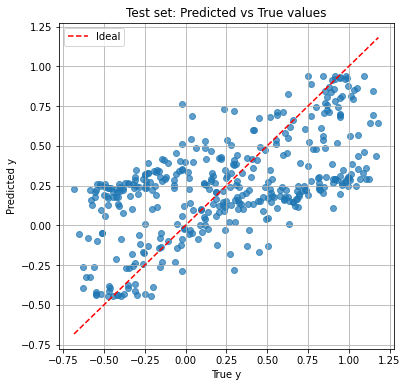

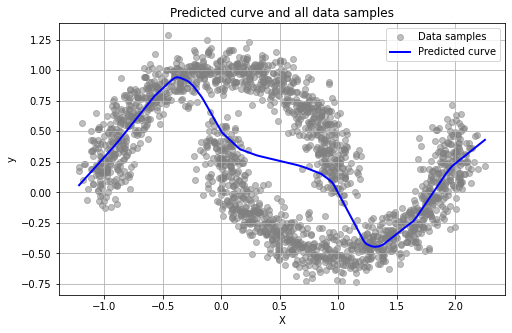

In [4]:
# Evaluate accuracy on the test dataset and plot y_pred vs y_true

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predict on test set
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_t).squeeze(1).numpy()

# Inverse transform predictions and true values to original scale
y_test_pred_orig = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
mse = mean_squared_error(y_test_orig, y_test_pred_orig)
r2 = r2_score(y_test_orig, y_test_pred_orig)
print(f"Test MSE: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")

# Plot y_pred vs y_true
plt.figure(figsize=(6, 6))
plt.scatter(y_test_orig, y_test_pred_orig, alpha=0.7)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', label='Ideal')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Test set: Predicted vs True values')
plt.legend()
plt.grid(True)
plt.show()

# Plot predicted curve on X, together with all data samples
# Predict on a dense grid of X values
X_all = np.vstack([X_train, X_test])  # all original X samples
y_all = np.concatenate([y_train, y_test])  # all original y samples

# Create a dense grid over the range of X
X_min, X_max = X_all.min(), X_all.max()
X_grid = np.linspace(X_min, X_max, 200).reshape(-1, 1)
X_grid_scaled = scaler_X.transform(X_grid)

model.eval()
with torch.no_grad():
    y_grid_pred_scaled = model(torch.from_numpy(X_grid_scaled).float()).squeeze(1).numpy()
y_grid_pred = scaler_y.inverse_transform(y_grid_pred_scaled.reshape(-1, 1)).flatten()

# Plot all data samples and predicted curve
plt.figure(figsize=(8, 5))
plt.scatter(X_all, y_all, color='gray', alpha=0.5, label='Data samples')
plt.plot(X_grid, y_grid_pred, color='blue', linewidth=2, label='Predicted curve')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Predicted curve and all data samples')
plt.legend()
plt.grid(True)
plt.show()

#### Part 3. Build Mixture Density Network to Learn the Function in a Probabilistic Way with Multiple Probabilistic Components

In [5]:
# Mixture Density Network (MDN) for 1D regression
class MDN(nn.Module):
    def __init__(self, n_hidden=64, n_components=2):
        super().__init__()
        self.n_components = n_components
        self.net = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
        )
        self.pi_head = nn.Linear(n_hidden, n_components)
        self.mu_head = nn.Linear(n_hidden, n_components)
        self.log_sigma_head = nn.Linear(n_hidden, n_components)
    def forward(self, x):
        h = self.net(x)
        pi = nn.functional.softmax(self.pi_head(h), dim=1)
        mu = self.mu_head(h)
        log_sigma = self.log_sigma_head(h)
        sigma = torch.exp(log_sigma)
        return pi, mu, sigma

def mdn_loss(y, pi, mu, sigma):
    # y: (batch, 1), pi/mu/sigma: (batch, n_components)
    y = y.expand_as(mu)
    comp = torch.exp(-0.5 * ((y - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    weighted = pi * comp
    prob = torch.sum(weighted, dim=1, keepdim=True)
    nll = -torch.log(prob + 1e-8)
    return torch.mean(nll)

n_components = 2
model = MDN(n_hidden=32, n_components=n_components)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Add a learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-4, verbose=True
)

# Train the model with checkpointing
train_losses = []
val_losses = []
num_epochs = 500
best_val_loss = float('inf')
best_model_path = "best_mdn_model.pt"

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    pi, mu, sigma = model(X_train_t)
    loss = mdn_loss(y_train_t, pi, mu, sigma)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation loss
    model.eval()
    with torch.no_grad():
        pi_val, mu_val, sigma_val = model(X_test_t)
        val_loss = mdn_loss(y_test_t, pi_val, mu_val, sigma_val)
        val_losses.append(val_loss.item())

    # Step the scheduler
    scheduler.step(val_loss.item())

    # Print train/val loss and lr every 20 epochs
    if (epoch + 1) % 20 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | LR: {current_lr:.6f}")

    # Save checkpoint if this is the best validation loss so far
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        torch.save(model.state_dict(), best_model_path)

# Load the best model after training
model.load_state_dict(torch.load(best_model_path))


d:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1 | Train Loss: 1.4196 | Val Loss: 1.3950 | LR: 0.010000
Epoch  20 | Train Loss: 1.1267 | Val Loss: 1.1849 | LR: 0.010000
Epoch  40 | Train Loss: 0.8083 | Val Loss: 0.8868 | LR: 0.010000
Epoch  60 | Train Loss: 0.6021 | Val Loss: 0.6983 | LR: 0.010000
Epoch  80 | Train Loss: 0.5734 | Val Loss: 0.6659 | LR: 0.010000
Epoch 100 | Train Loss: 0.5623 | Val Loss: 0.6593 | LR: 0.010000
Epoch 120 | Train Loss: 0.5606 | Val Loss: 0.6615 | LR: 0.010000
Epoch 140 | Train Loss: 0.5547 | Val Loss: 0.6530 | LR: 0.005000
Epoch 160 | Train Loss: 0.5527 | Val Loss: 0.6537 | LR: 0.002500
Epoch 180 | Train Loss: 0.5519 | Val Loss: 0.6525 | LR: 0.001250
Epoch 200 | Train Loss: 0.5516 | Val Loss: 0.6525 | LR: 0.000625
Epoch 220 | Train Loss: 0.5514 | Val Loss: 0.6524 | LR: 0.000313
Epoch 240 | Train Loss: 0.5514 | Val Loss: 0.6523 | LR: 0.000156
Epoch 260 | Train Loss: 0.5513 | Val Loss: 0.6523 | LR: 0.000156
Epoch 280 | Train Loss: 0.5513 | Val Loss: 0.6523 | LR: 0.000100
Epoch 300 | Train Loss: 0

C:\Temp/ipykernel_8736/2753263266.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


<All keys matched successfully>

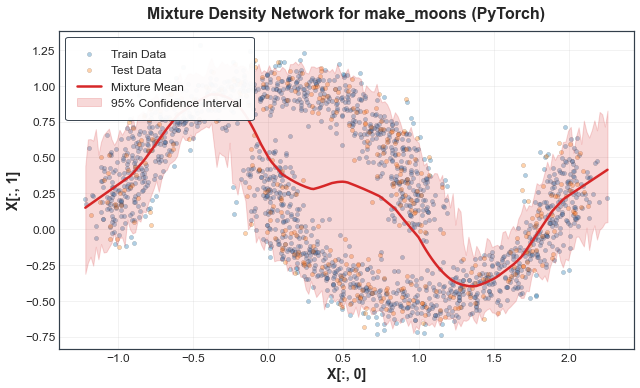

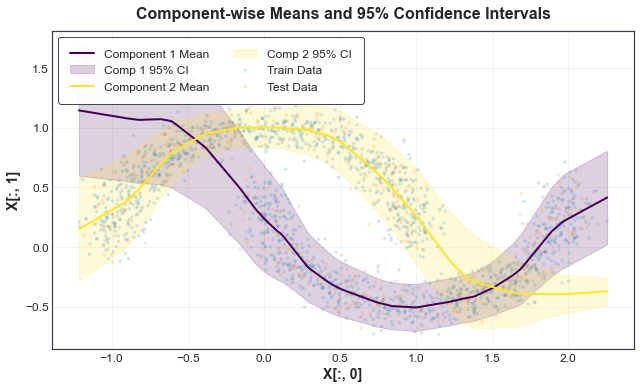

In [6]:
# Evaluate on the test dataset and compute relevant metrics
X_plot = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 200).reshape(-1, 1)
X_plot_t = torch.tensor(X_plot, dtype=torch.float32)
model.eval()
with torch.no_grad():
    pi_pred, mu_pred, sigma_pred = model(X_plot_t)
    # For visualization, use the mixture mean and sample from the mixture
    # Mixture mean:
    mean_pred = torch.sum(pi_pred * mu_pred, dim=1).numpy()
    # For confidence, sample from the mixture
    n_samples = 100
    samples = []
    for i in range(n_samples):
        # Sample component for each input
        comp = torch.multinomial(pi_pred, 1).squeeze(1)
        chosen_mu = mu_pred.gather(1, comp.unsqueeze(1)).squeeze(1)
        chosen_sigma = sigma_pred.gather(1, comp.unsqueeze(1)).squeeze(1)
        sample = torch.normal(chosen_mu, chosen_sigma)
        samples.append(sample.numpy())
    samples = np.stack(samples, axis=1)  # shape: (n_points, n_samples)
    # Compute 2.5 and 97.5 percentiles for 95% interval
    lower = np.percentile(samples, 2.5, axis=1)
    upper = np.percentile(samples, 97.5, axis=1)

# Inverse transform to original scale
mean_pred_orig = scaler_y.inverse_transform(mean_pred.reshape(-1, 1)).flatten()
lower_orig = scaler_y.inverse_transform(lower.reshape(-1, 1)).flatten()
upper_orig = scaler_y.inverse_transform(upper.reshape(-1, 1)).flatten()
X_plot_orig = scaler_X.inverse_transform(X_plot).flatten()

import matplotlib as mpl

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'lines.linewidth': 2,
    'axes.edgecolor': '#333F4B',
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.fancybox': True,
    'legend.edgecolor': '#333F4B'
})

# Plot predictions with 95% confidence interval
fig, ax = plt.subplots(figsize=(9, 5.5))
scatter_train = ax.scatter(
    X_train, y_train, s=18, alpha=0.35, label='Train Data', color='#1f77b4', edgecolor='k', linewidth=0.3
)
scatter_test = ax.scatter(
    X_test, y_test, s=18, alpha=0.35, label='Test Data', color='#ff7f0e', edgecolor='k', linewidth=0.3
)
mean_line, = ax.plot(
    X_plot_orig, mean_pred_orig, color='#d62728', label='Mixture Mean', linewidth=2.5
)
conf_fill = ax.fill_between(
    X_plot_orig,
    lower_orig,
    upper_orig,
    color='#d62728', alpha=0.18, label='95% Confidence Interval'
)
ax.set_xlabel('X[:, 0]')
ax.set_ylabel('X[:, 1]')
ax.set_title('Mixture Density Network for make_moons (PyTorch)', pad=12)
ax.legend(loc='upper left', frameon=True, fancybox=True, borderpad=1)
plt.tight_layout()
plt.show()

# Plot mean and 95% confidence interval for each component
# We'll use the predicted mu_pred and sigma_pred for each component
n_components = mu_pred.shape[1]
colors = plt.cm.viridis(np.linspace(0, 1, n_components))

fig_comp, ax_comp = plt.subplots(figsize=(9, 5.5))
for k in range(n_components):
    # Get mean and 95% interval for component k
    mu_k = mu_pred[:, k].numpy()
    sigma_k = sigma_pred[:, k].numpy()
    # 95% confidence interval for normal: mean ± 1.96 * std
    lower_k = mu_k - 1.96 * sigma_k
    upper_k = mu_k + 1.96 * sigma_k
    # Inverse transform to original scale
    mu_k_orig = scaler_y.inverse_transform(mu_k.reshape(-1, 1)).flatten()
    lower_k_orig = scaler_y.inverse_transform(lower_k.reshape(-1, 1)).flatten()
    upper_k_orig = scaler_y.inverse_transform(upper_k.reshape(-1, 1)).flatten()
    # Plot
    ax_comp.plot(
        X_plot_orig, mu_k_orig, color=colors[k], label=f'Component {k+1} Mean', linewidth=2
    )
    ax_comp.fill_between(
        X_plot_orig, lower_k_orig, upper_k_orig, color=colors[k], alpha=0.18, label=f'Comp {k+1} 95% CI'
    )

# Optionally, overlay the data
ax_comp.scatter(
    X_train, y_train, s=12, alpha=0.18, color='#1f77b4', label='Train Data', edgecolor='none'
)
ax_comp.scatter(
    X_test, y_test, s=12, alpha=0.18, color='#ff7f0e', label='Test Data', edgecolor='none'
)
ax_comp.set_xlabel('X[:, 0]')
ax_comp.set_ylabel('X[:, 1]')
ax_comp.set_title('Component-wise Means and 95% Confidence Intervals', pad=12)
ax_comp.legend(loc='upper left', frameon=True, fancybox=True, borderpad=1, ncol=2)
plt.tight_layout()
plt.show()

#### Part 4. Build Ensemble Learning Models

Random Forest Test MSE: 0.2503
Random Forest Test R2: 0.0503


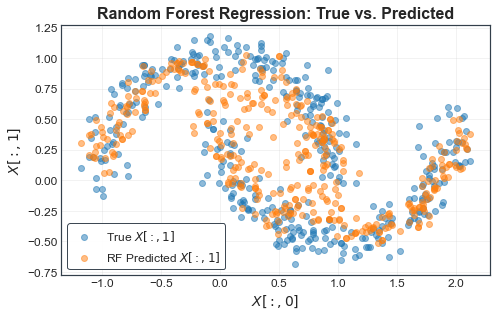

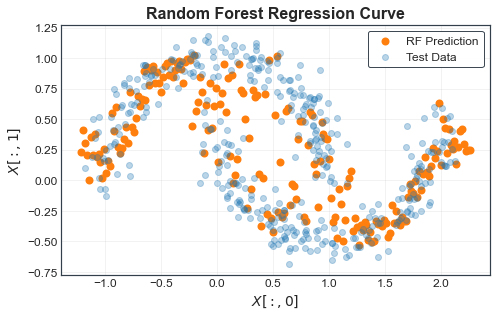

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train a Random Forest regressor on the same data
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train_scaled)

# Predict on test set
y_rf_test_pred_scaled = rf.predict(X_test_scaled)
y_rf_test_pred = scaler_y.inverse_transform(y_rf_test_pred_scaled.reshape(-1, 1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# Evaluate performance
mse_rf = mean_squared_error(y_test_orig, y_rf_test_pred)
r2_rf = r2_score(y_test_orig, y_rf_test_pred)
print(f"Random Forest Test MSE: {mse_rf:.4f}")
print(f"Random Forest Test R2: {r2_rf:.4f}")

# Plot Random Forest predictions vs. ground truth
plt.figure(figsize=(7, 4.5))
plt.scatter(X_test, y_test_orig, color='#1f77b4', alpha=0.5, label='True $X[:, 1]$')
plt.scatter(X_test, y_rf_test_pred, color='#ff7f0e', alpha=0.5, label='RF Predicted $X[:, 1]$')
plt.xlabel('$X[:, 0]$')
plt.ylabel('$X[:, 1]$')
plt.title('Random Forest Regression: True vs. Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# Plot RF prediction curve on the same X_plot_orig as MDN
y_rf_plot_pred_scaled = rf.predict(X_plot)
y_rf_plot_pred = scaler_y.inverse_transform(y_rf_plot_pred_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(7, 4.5))
plt.scatter(X_plot_orig, y_rf_plot_pred, color='#ff7f0e', label='RF Prediction', linewidth=2)
plt.scatter(X_test, y_test_orig, color='#1f77b4', alpha=0.3, label='Test Data')
plt.xlabel('$X[:, 0]$')
plt.ylabel('$X[:, 1]$')
plt.title('Random Forest Regression Curve')
plt.legend()
plt.tight_layout()
plt.show()
